# Getting started with Cacoa

Cacoa compares samples (patients, donors, replicates) across conditions. One **model** is set once and used by every analysis: expression shifts per cell type, composition, differential expression, cell density and the cluster-free analyses.

The recommended order is

1. `Cacoa$new()` with the sample metadata. No model is needed yet; a summary of the metadata is printed.
2. `cao$checkDesign()`, `cao$plotDesign()`: confounding, balance, degrees of freedom and permutation feasibility, from the metadata alone.
3. `cao$screenCovariates()`, `cao$plotCovariateScreen()`: which covariates are associated with sample-level variation, and in which cell types (exploratory).
4. `cao$setModel(~ condition + batch, test = "condition")`: the model used from here on.
5. `cao$estimateExpressionShiftMagnitudes()`, `cao$plotExpressionShiftMagnitudes()` and the other analyses.
6. `cao$checkSensitivity()`, `cao$plotSensitivity()`: is the result robust to the covariate set and to single samples?

This notebook runs the workflow on a **simulated** dataset: a Conos object with 40 samples (4 groups x 2 batches, 5 samples each) and 9 cell types of 500 cells. Expression differences between `Group2` and `Group1` were planted with a known strength per cell type: strong in `IN-SST`, `IN-PV` and `L2/3`; moderate in `OPC`, `L5/6-CC` and `AST-PP`; weak in `AST-FB`; none in `Microglia` and `Neu-NRGN`. The object is not shipped with the package (720 MB); the notebook is provided for reading, with its outputs. The same code runs on any Conos or Seurat object with a sample metadata table.

> GitHub's notebook preview runs its math renderer over code cells, so R code containing `$` is displayed incorrectly there. For reading on GitHub use [walkthrough_short.md](walkthrough_short.md), the same notebook rendered as Markdown. The `.ipynb` is for Jupyter, VS Code and nbviewer.

In [1]:
library(conos)
library(cacoa)
library(ggplot2)
library(cowplot)

## Load data

`sample.metadata` is a data frame with one row per sample (row names are the sample names) and one column per covariate. Here it has the group, the batch and two technical columns from the simulation. A random `age` column is added to show how an unrelated covariate is treated.

In [2]:
sim <- readRDS("../test/shifts_sim_objects.rds")$with_batch                      # a Cacoa object from an earlier version
con <- sim$data.object                                 # the Conos object inside it
sample.meta <- con$misc$sample_meta
set.seed(1); sample.meta$age <- round(rnorm(nrow(sample.meta), 55, 8))   # unrelated to the groups, for illustration
head(sample.meta)

                       ExpLibSize sizeFactor  Batch  Group age
Sample_Group1_Batch1_1   7633.677  1.0950848 Batch1 Group1  50
Sample_Group1_Batch1_2   6533.826  1.0370354 Batch1 Group1  56
Sample_Group1_Batch1_3   4536.694  0.9406133 Batch1 Group1  48
Sample_Group1_Batch1_4   6645.566  1.0131826 Batch1 Group1  68
Sample_Group1_Batch1_5   6413.484  0.9948789 Batch1 Group1  58
Sample_Group1_Batch2_1   6652.652  0.9957633 Batch2 Group1  48

In [3]:
cao <- Cacoa$new(con, sample.metadata = sample.meta, cell.groups = sim$cell.groups, sample.per.cell = sim$sample.per.cell, n.cores = 16)
cao$plot.params <- list(size = 0.3, alpha = 0.3, font.size = c(2, 3))

Sample metadata: 40 samples, 5 columns
  usable (5): ExpLibSize [num, 3529-8743], sizeFactor [num, 0.874-1.11], Batch [Batch1 20, Batch2 20], Group [4 levels], age [num, 37-68]
Next: cao$checkDesign() and cao$screenCovariates(), or cao$setModel(test = "<variable>").

The constructor prints which metadata columns can be used as covariates and which cannot (ID-like, constant, mostly missing, too many levels). The previous two-group constructor (`sample.groups`, `ref.level`, `target.level`) still works and is translated into a `condition` column and `test = "condition"`.

Options shared by all methods are set once; explicit arguments of a method call still win.

In [4]:
cao$setOptions(n.permutations = 499, seed = 1)

## Check the design

Before fitting anything, the metadata alone tells whether the planned comparison can be adjusted for the other covariates: associations between covariates (bias-corrected Cramer's V, correlation ratio, Spearman correlation), balance of the groups over the covariates, aliasing, degrees of freedom and how many distinct permutations the design allows.

In [5]:
chk <- cao$checkDesign(test = "Group")
chk

Design check: 40 samples, 5 covariates, test variable 'Group'
  association with 'Group': ExpLibSize 0.81, sizeFactor 0.24, age 0.17, Batch 0.00
  Warning (1):
    - 'ExpLibSize' is strongly associated with 'Group' (0.81): adjusting for it estimates the Group effect not explained by ExpLibSize -> consider reporting both models (cao$checkSensitivity())
Design check: 40 samples, 5 covariates, test variable 'Group'
  association with 'Group': ExpLibSize 0.81, sizeFactor 0.24, age 0.17, Batch 0.00
  Warning (1):
    - 'ExpLibSize' is strongly associated with 'Group' (0.81): adjusting for it estimates the Group effect not explained by ExpLibSize -> consider reporting both models (cao$checkSensitivity())

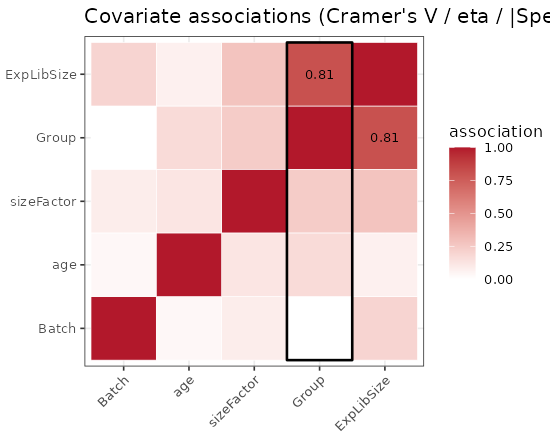

In [6]:
cao$plotDesign("associations")

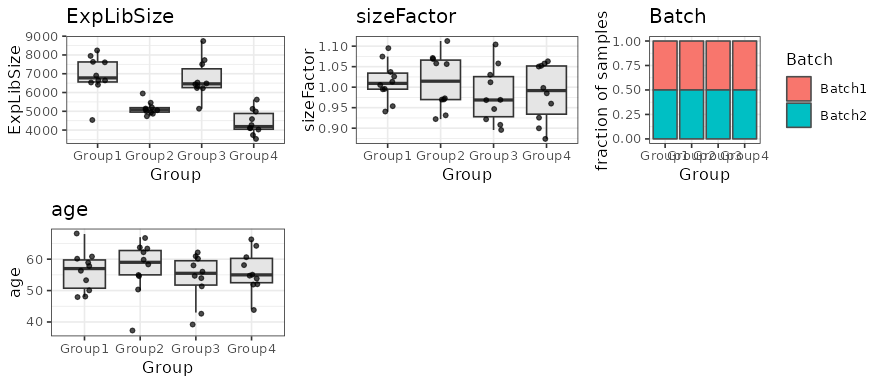

In [7]:
cao$plotDesign("balance")

The report lists errors (a covariate that fully determines the condition), warnings (strongly associated covariates, small groups, few distinct permutations) and notes, each with a suggestion. Here the design is balanced and nothing is flagged.

## Screen covariates

The screen tests every usable covariate against the sample-to-sample expression distances of each cell type, **marginally** (alone) and **partially** (adjusted for all other covariates). A covariate that is significant only marginally is explained by the others (shown as a ring in the plot). The last column is a global test over all cell types. The screen ends with a suggested model; it is not applied automatically.

In [8]:
scr <- cao$screenCovariates(n.permutations = 199)
scr

Covariate screen: 5 covariates x 9 cell types, marginal + partial mode, permutation p-values (199 permutations)
Associated with expression in >= 2 cell types (partial, FDR 5%): Batch (9 types, global p 0.005), Group (7 types, global p 0.005)
Marginal only (explained by other covariates): ExpLibSize
Associated with sample dispersion: Batch (4 types), Group (6 types)
Suggested model: ~Batch + Group   (not applied; see cao$setModel())
Covariate screen: 5 covariates x 9 cell types, marginal + partial mode, permutation p-values (199 permutations)
Associated with expression in >= 2 cell types (partial, FDR 5%): Batch (9 types, global p 0.005), Group (7 types, global p 0.005)
Marginal only (explained by other covariates): ExpLibSize
Associated with sample dispersion: Batch (4 types), Group (6 types)
Suggested model: ~Batch + Group   (not applied; see cao$setModel())

Building pseudobulk profiles per cell type...
Computing sample distances (cor)...

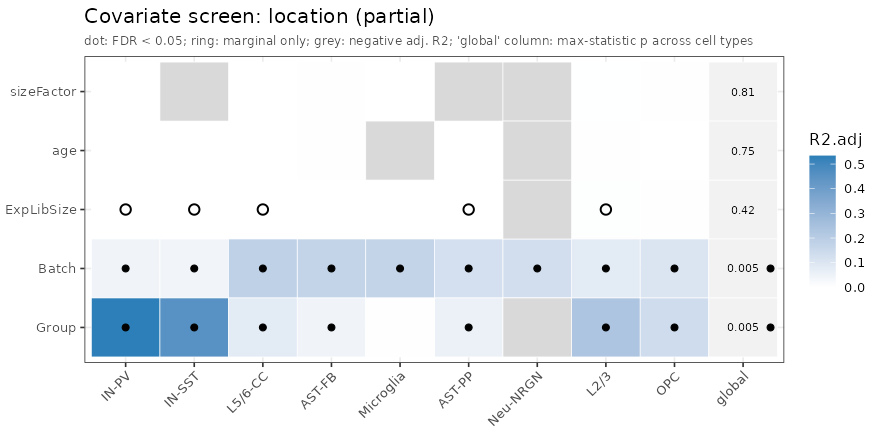

In [9]:
cao$plotCovariateScreen()

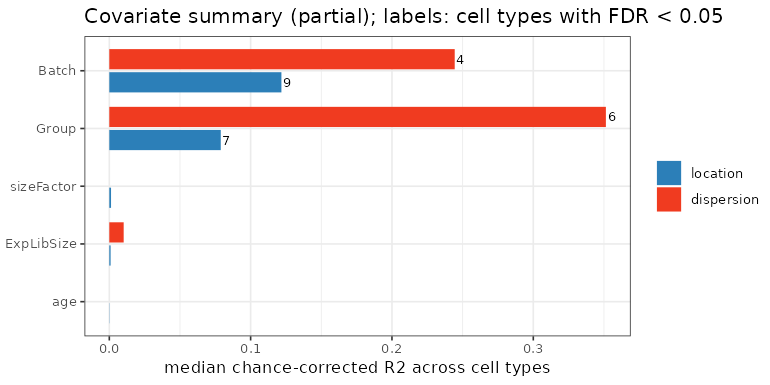

In [10]:
cao$plotCovariateSummary()

Variance partition: how much of the sample-level variation is explained uniquely by each covariate, shared between them, or left unexplained.

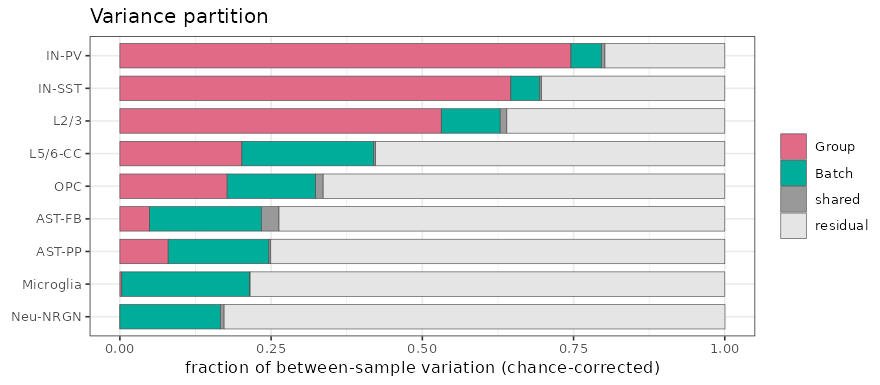

In [11]:
cao$plotVariancePartition(c("Group", "Batch"))

## Set the model

`test` accepts a variable name (two levels: a contrast with an automatically chosen reference; numeric: a slope per unit; a factor with more levels needs the comparison, e.g. `"Group: Group2 vs Group1"`, or `"Group: all"` for a whole-factor test), an explicit comparison such as `"Group: Group2 vs Group1"`, several variables, `"all"`, or a structured contrast. The printout states the reference level and how it was chosen, the adjustment set, the permutation scheme and the number of distinct permutations.

Here two tests are set: the planted contrast `Group2 vs Group1`, and the whole-factor test of `Group` over all four groups. Both are adjusted for `Batch`.

In [12]:
cao$setModel(~ Group + Batch, test = c("Group: Group2 vs Group1", "Group: all"))

Model: ~Group + Batch      dispersion: ~Group
Test 1: Group: Group2 vs Group1  (reference 'Group1': as requested)
       adjusted for Batch; permutations: block within 2 strata (63,504 distinct)
       shift > 0: Group2 samples differ from Group1 samples in a common direction, beyond within-group variability
Test 2: Group (4 levels)
       adjusted for Batch; permutations: block within 2 strata (1.376573e+20 distinct)
       location: the levels of Group differ in where their samples sit (a common direction per level), beyond within-level variability
Samples: 40 used.   Issues: none

## Expression shifts per cell type

The expression shift is estimated with an individual-level model fitted to the sample-sample distances of each cell type. Three effects are reported for a contrast:

| effect | meaning |
|---|---|
| `shift` | the groups differ in a common direction, beyond within-group variability |
| `var`   | the target group is more (or less) heterogeneous than the reference group |
| `total` | target samples are farther from reference samples than reference samples are from each other (`shift + var/2`) |

For a whole-factor test the effects are `location` (any group differs) and `dispersion` (the groups differ in heterogeneity). P-values come from permutations (block randomization within batches here); they are adjusted across cell types by Benjamini-Hochberg (`padj`) and by the max-statistic (`p.fwer`), and a global p-value per test is reported.

In [13]:
res <- cao$estimateExpressionShiftMagnitudes()
subset(res$results, effect == "shift")[, c("celltype", "estimate", "estimate.norm", "se.jk", "p", "padj", "p.fwer", "n")]

   celltype      estimate estimate.norm       se.jk     p        padj p.fwer  n
1      L2/3  1.374823e+00  5.4631680091 0.046833489 0.002 0.003000000  0.002 27
2   L5/6-CC  6.020653e-01  1.2102944470 0.030331326 0.002 0.003000000  0.002 25
3     IN-PV  5.991260e-01  2.5695122290 0.014427978 0.002 0.003000000  0.002 25
4    IN-SST  5.591125e-01  1.4179455088 0.031013333 0.002 0.003000000  0.002 28
5       OPC  1.905223e-01  0.2696599533 0.014984638 0.002 0.003000000  0.002 26
6    AST-PP  1.019428e-01  0.1303749451 0.009408382 0.002 0.003000000  0.002 29
7    AST-FB  6.760441e-02  0.0892437353 0.013439290 0.004 0.005142857  0.006 25
8 Microglia -9.598212e-05 -0.0001201521 0.007312462 0.480 0.540000000  0.966 29
9  Neu-NRGN -7.255550e-03 -0.0088341840 0.007367258 0.986 0.986000000  1.000 30

Testing 9 cell type(s), 2 test(s), 499 permutations (auto)...
7 of 9 cell types with a significant shift at FDR 5% (global p = 0.002, 0.002).

In [14]:
res$global

      effect     p                    test test.id
1      shift 0.002 Group: Group2 vs Group1       1
2        var 0.002 Group: Group2 vs Group1       1
3      total 0.002 Group: Group2 vs Group1       1
4   location 0.002        Group (4 levels)       2
5 dispersion 0.002        Group (4 levels)       2

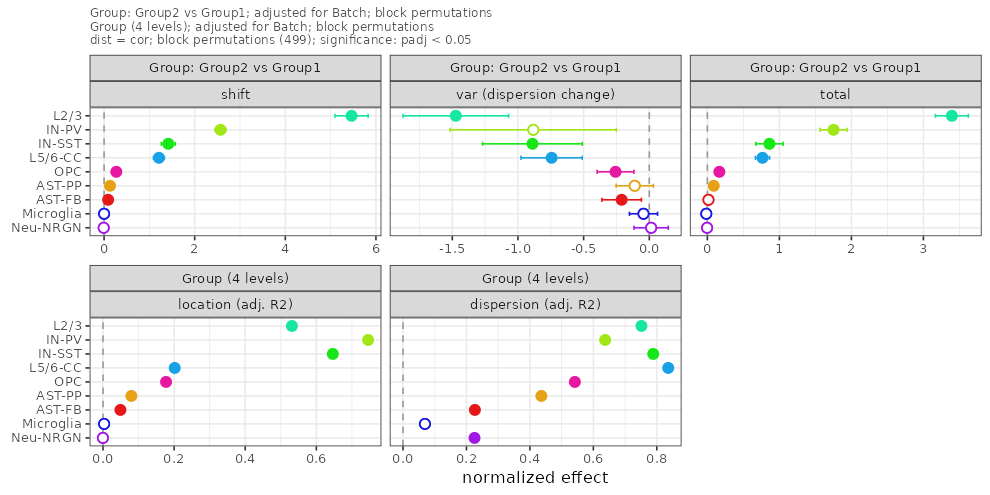

In [15]:
cao$plotExpressionShiftMagnitudes()

Points are normalized effects with jackknife intervals; filled points are significant after Benjamini-Hochberg adjustment across cell types. The subtitle records the test, the adjustment set and the permutation scheme. The planted strong cell types come out on top and the two unchanged ones at the bottom.

The second test (all four groups) is plotted by name.

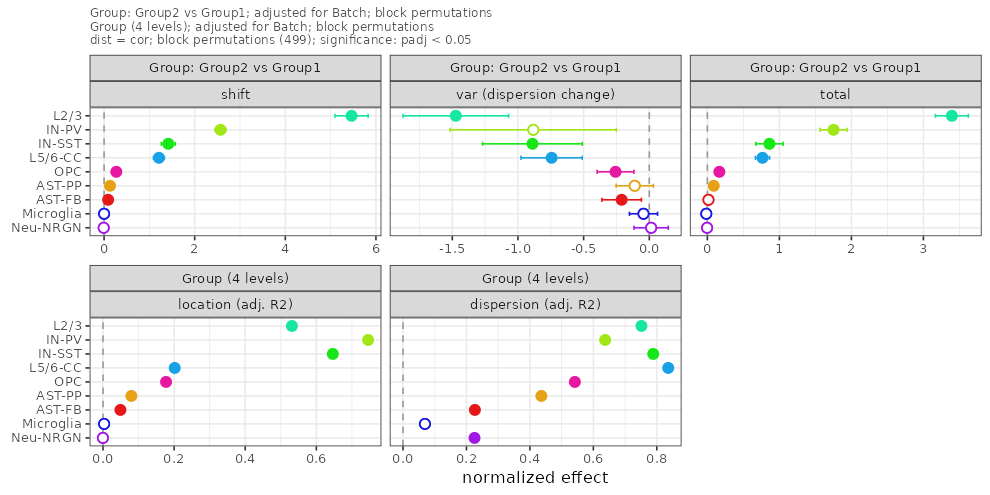

In [16]:
cao$plotExpressionShiftMagnitudes(test = "Group")

### Behind one cell type

`plotShiftDetail()` shows the sample-level picture: the distance distribution within and between groups, and the samples in the adjusted distance space.

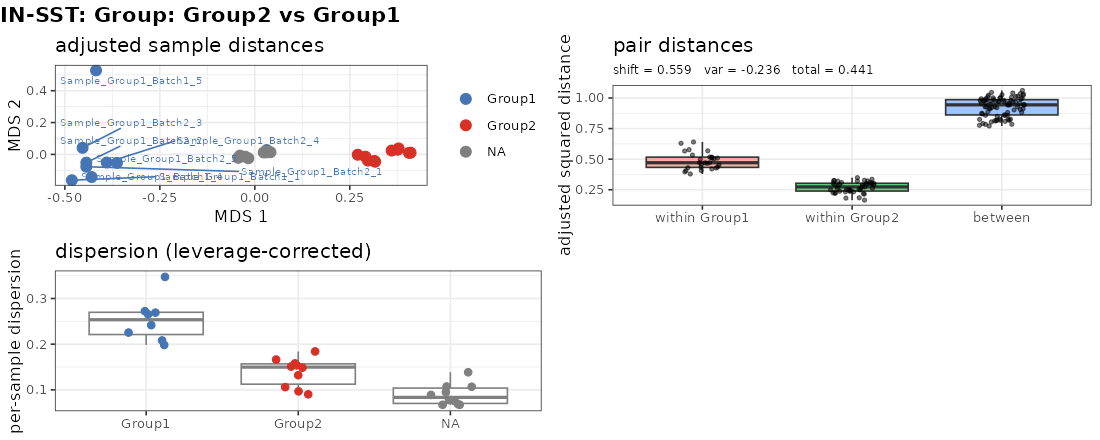

In [17]:
cao$plotShiftDetail("IN-SST")

`plotSampleInfluence()` shows how much each sample changes the shift estimate when it is left out.

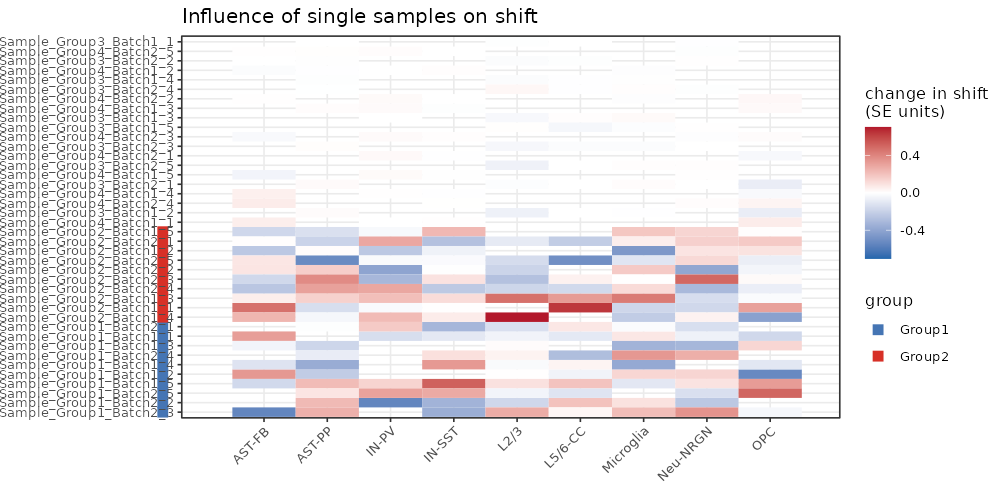

In [18]:
cao$plotSampleInfluence()

## Robustness

The expression shifts are re-estimated without adjustment, with the current model, without each covariate, and with the top covariates proposed by the screen. Per cell type, one verdict summarizes the result: robust, sign or significance depends on the adjustment, the estimate changes by more than half, or the result is driven by one sample.

In [19]:
sens <- cao$checkSensitivity(n.permutations = 199)
sens

Sensitivity of 'Group: Group2 vs Group1' (shift) across 2 models: unadjusted [~Group]; current [~Group + Batch]
  L2/3                 robust (significant in 2 of 2 models)
  L5/6-CC              robust (significant in 2 of 2 models)
  IN-PV                robust (significant in 2 of 2 models)
  IN-SST               robust (significant in 2 of 2 models)
  OPC                  robust (significant in 2 of 2 models)
  AST-PP               significance depends on adjustment (unadjusted) (significant in 1 of 2 models)
  AST-FB               significance depends on adjustment (unadjusted) (significant in 1 of 2 models)
  Neu-NRGN             driven by sample Sample_Group2_Batch2_3 (significant in 0 of 2 models)
  Microglia            driven by sample Sample_Group2_Batch1_2 (significant in 0 of 2 models)
Sensitivity of 'Group: Group2 vs Group1' (shift) across 2 models: unadjusted [~Group]; current [~Group + Batch]
  L2/3                 robust (significant in 2 of 2 models)
  L5/6-CC         

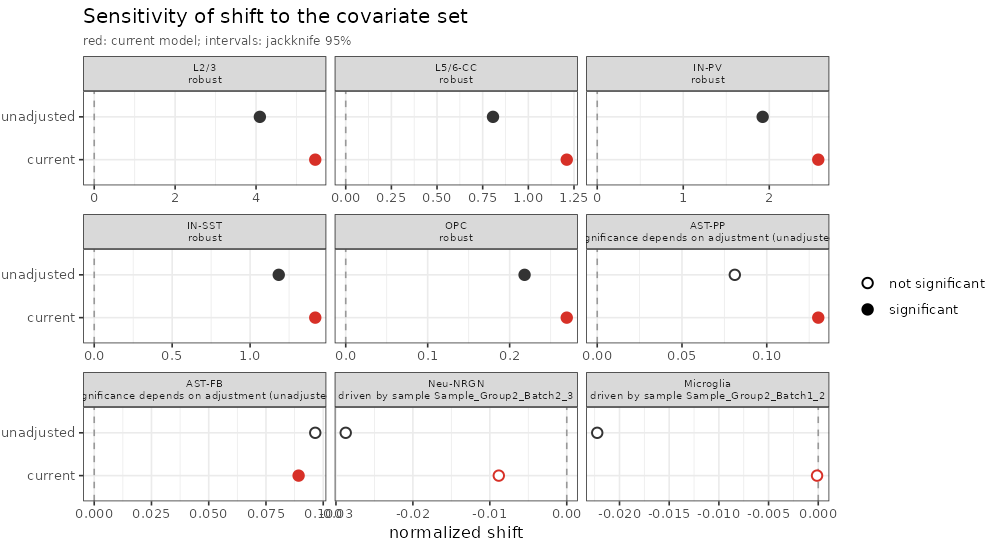

In [20]:
cao$plotSensitivity()

## Sample structure

The sample distances of one cell type (or of all cell types jointly) can be shown as is, or after removing the part explained by a covariate (`adjust.for`).

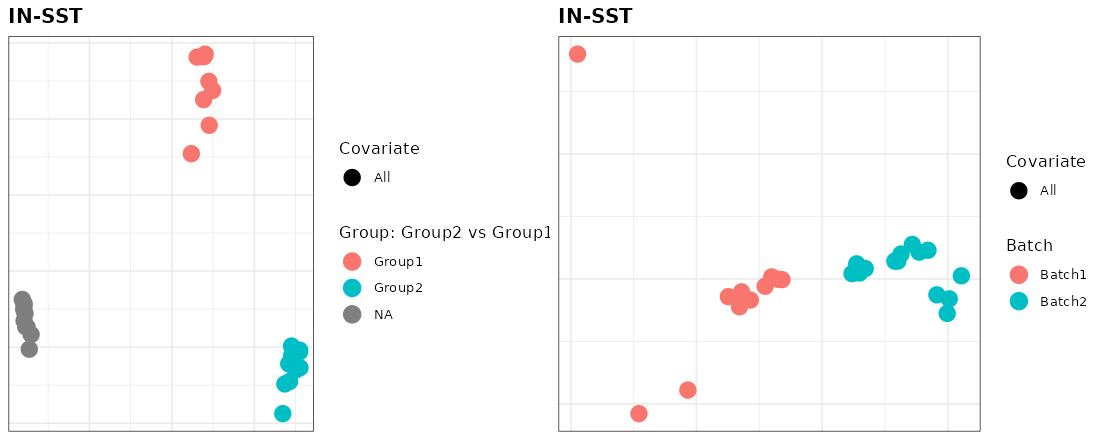

In [21]:
plot_grid(
  cao$plotSampleDistances(space = "expression.shifts", cell.type = "IN-SST", color.by = "test", values = "unadjusted"),
  cao$plotSampleDistances(space = "expression.shifts", cell.type = "IN-SST", color.by = "Batch", adjust.for = ~ Group),
  ncol = 2)

## Differential expression and composition on the same model

The stored model (formula, test, reference level) is used by the per-cell-type differential expression, by the compositional analysis and by the cell density analysis, and is recorded with each result. Whole-factor tests are routed to the corresponding multi-group tests (DESeq2 LRT, edgeR/limma F).

In [22]:
de <- cao$estimateDEPerCellType(test = "limma-voom", min.cell.count = 5)
sapply(de, function(d) sum(d$res$padj < 0.05, na.rm = TRUE))             # DE genes per cell type

   AST-FB    AST-PP     IN-PV    IN-SST      L2/3   L5/6-CC Microglia  Neu-NRGN 
        1        32       180       155       195       194         0         1 
      OPC 
       42 

Preparing matrices for DE
Estimating DE per cell type

The top genes of one cell type (`cao$plotVolcano()` draws them when the EnhancedVolcano package is installed):

In [23]:
r <- de[["IN-SST"]]$res; r <- r[order(r$padj), intersect(c("Gene", "log2FoldChange", "stat", "pvalue", "padj", "CellFrac"), names(r))]
head(r, 8)

             Gene log2FoldChange     stat       pvalue         padj CellFrac
Gene2526 Gene2526       4.375769 27.16084 2.629970e-29 8.068748e-26        1
Gene2406 Gene2406       4.561623 23.05506 2.377341e-26 3.646841e-23        1
Gene2241 Gene2241       1.934041 20.52814 2.675029e-24 2.735663e-21        1
Gene900   Gene900       3.545056 15.18251 3.383617e-19 2.595234e-16        1
Gene1104 Gene1104       3.076600 14.71285 1.089375e-18 6.684404e-16        1
Gene303   Gene303       3.536437 14.44891 2.124928e-18 1.086546e-15        1
Gene3095 Gene3095       3.455485 14.25701 3.471353e-18 1.521445e-15        1
Gene3646 Gene3646       3.237676 14.02310 6.351357e-18 2.435745e-15        1

Running lmCoda with design='~Group + Batch' and freedman-lane permutations

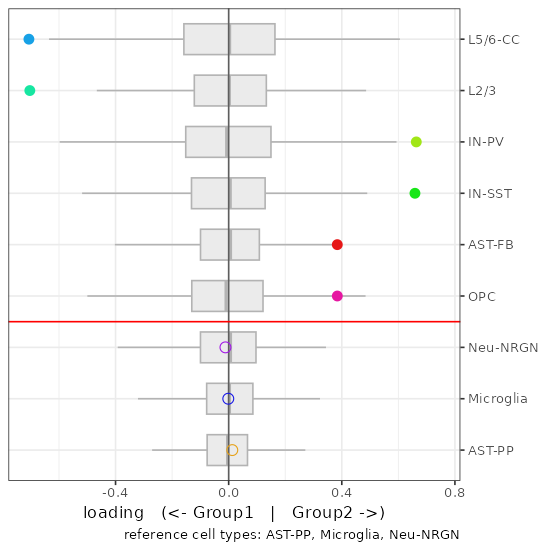

In [24]:
cao$estimateCellLoadings()
cao$plotCellLoadings(show.pvals = FALSE)

## Cluster-free analyses

Cell density is compared between the two groups using the regression weights of the contrast, so adjusted covariates are accounted for. Cluster-free expression shifts test the same contrast in every cell's neighbourhood, sharing the permutations across cells and adjusting the z-scores by the maximum statistic.

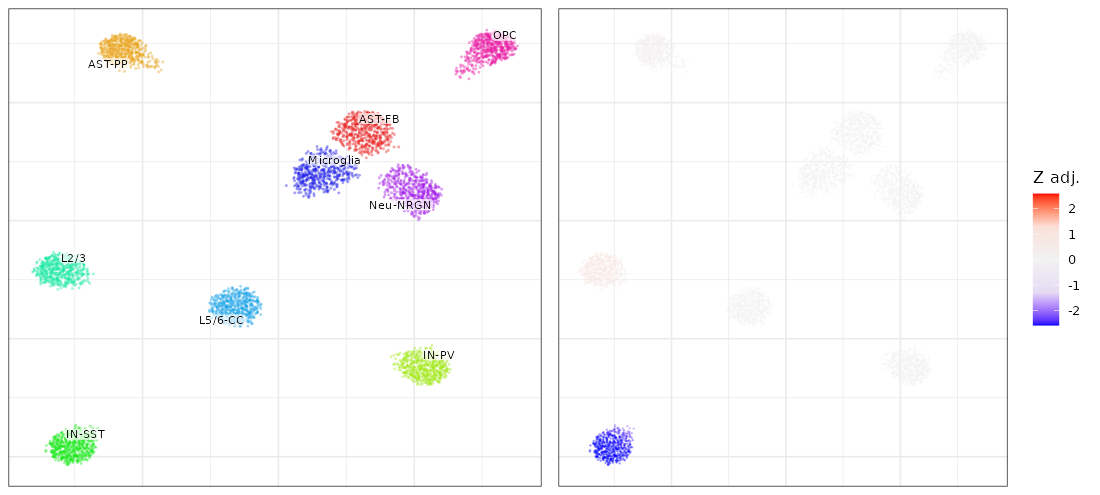

In [25]:
cao$estimateCellDensity(method = "graph")
cao$estimateDiffCellDensity(type = "permutation")
plot_grid(cao$plotEmbedding(color.by = "cell.groups"), cao$plotDiffCellDensity(), ncol = 2)

Testing 4500 cells (40 samples) with 99 permutations (block)...

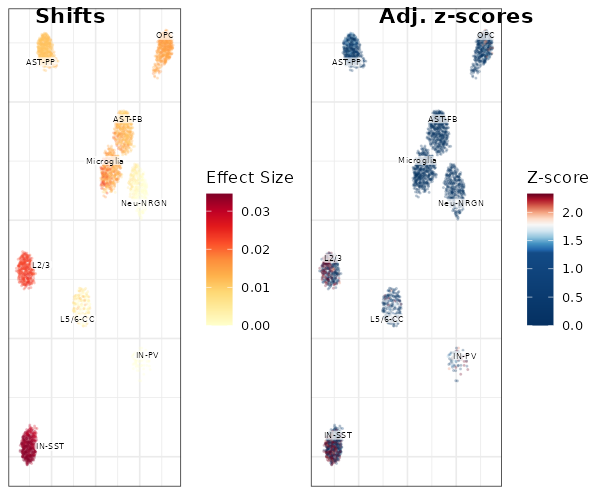

In [26]:
cao$estimateClusterFreeExpressionShifts(n.top.genes = 500, n.permutations = 99)
cao$plotClusterFreeExpressionShifts(font.size = 2)

## Session info

In [27]:
sessionInfo()

R version 4.2.2 Patched (2022-11-10 r83330)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/blas/libblas.so.3.9.0
LAPACK: /usr/lib/x86_64-linux-gnu/lapack/liblapack.so.3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] cowplot_1.2.0  ggplot2_4.0.2  conos_1.5.4    igraph_2.1.4   cacoa_0.5.0   
[6] Matrix_1.6-1.1

loaded via a namespace (and not attached):
  [1] spatstat.univar_3.1-4       circlize_0.4.16            
  [3] systemfonts_1.0.4           plyr_1.8.9     